In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn import preprocessing

In [2]:
df_admits = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar_detail.csv.gz', compression='gzip')


In [3]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar_detail.csv.gz', compression='gzip')


In [32]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
print(df_medi.head(10))
print(len(df_medi))

   subject_id     hadm_id      emar_id  emar_seq       poe_id  pharmacy_id  \
0    10000032  22595853.0  10000032-10        10  10000032-32   86768272.0   
1    10000032  22595853.0  10000032-11        11  10000032-37   43092008.0   
2    10000032  22595853.0  10000032-12        12  10000032-27   30740602.0   
3    10000032  22595853.0  10000032-13        13  10000032-36          NaN   
4    10000032  22595853.0  10000032-14        14  10000032-35          NaN   
5    10000032  22595853.0  10000032-15        15  10000032-38          NaN   
6    10000032  22595853.0  10000032-16        16  10000032-42          NaN   
7    10000032  22595853.0  10000032-17        17  10000032-33   73243129.0   
8    10000032  22595853.0  10000032-18        18  10000032-55   12775705.0   
9    10000032  22595853.0  10000032-19        19  10000032-56   46308055.0   

  enter_provider_id            charttime                   medication  \
0               NaN  2180-05-07 07:51:00                      Hepari

In [35]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


,deathtime,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,edregtime,edouttime
0,NaN,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,2180-05-06 19:17:00,2180-05-06 23:30:00
1,NaN,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-06-26 15:54:00,2180-06-26 21:31:00
2,NaN,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,2180-08-05 20:58:00,2180-08-06 01:44:00
3,NaN,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-07-23 05:54:00,2180-07-23 14:00:00
4,NaN,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,2160-03-03 21:55:00,2160-03-04 06:26:00
...,...,...,...,...,...,...,...,...,...
546023,NaN,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2149-01-08 09:11:00,2149-01-08 18:12:00
546024,NaN,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2147-07-17 17:18:00,2147-07-18 17:34:00
546025,2164-09-17 13:42:00,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,2164-09-10 11:09:00,2164-09-10 14:46:00
546026,NaN,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,2164-07-24 21:16:00,2164-07-25 01:20:00


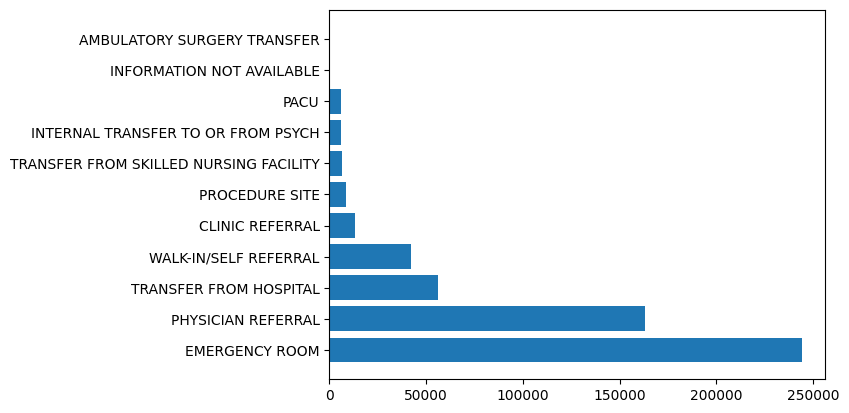

In [6]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [4]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')

In [5]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis.rename(columns={'long_title': 'icd_diagnosis_name'}, inplace=True)
df_admit_diagnosis.head(5)

,subject_id_x,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,subject_id_y,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,1.0,5723,9.0,9.0,Portal hypertension
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,2.0,78959,9.0,9.0,Other ascites
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas..."


In [ ]:
# Next stage
# 1 - Group text fields
# 2 - Enocode catgeorical features
# 3 - Assign appointment readimission instance flags

In [9]:
# 1. 
# 
# Check for how many diagnosis that exist - will need to group diagnosis first for easier encoding
pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
#pd.reset_option('display.max_rows')

print(df_admit_diagnosis.icd_diagnosis_name.value_counts())

icd_diagnosis_name
Unspecified essential hypertension                                                                                                                                                                                             102368
Hyperlipidemia, unspecified                                                                                                                                                                                                     84570
Essential (primary) hypertension                                                                                                                                                                                                83775
Other and unspecified hyperlipidemia                                                                                                                                                                                            67293
Acute kidney failure, unspecified                            

In [6]:
#pd.reset_option('display.max_rows')
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis[df_admit_diagnosis['icd_diagnosis_name'].isna()]

,subject_id_x,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,subject_id_y,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name


In [7]:
# Apply K-means clustering for text column
# Inital vectorizer step is key for good clustering - add in custom conditions for stop words and removal of common words

vectorizer = TfidfVectorizer(
                            #stop_words='english',
                             ngram_range=(1, 2),    # combines phrases  
                             max_df=0.95)           # removes common words
vectorized_words = vectorizer.fit_transform(df_admit_diagnosis['icd_diagnosis_name'])


In [8]:
svd = TruncatedSVD(n_components=2, random_state=42)
reduced_data = svd.fit_transform(vectorized_words)

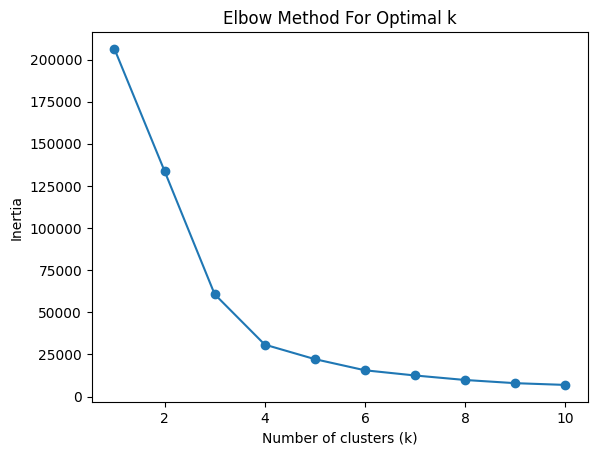

In [9]:
# Use Elbow Method to determine the number of clusters to use

inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced_data)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias.append(kmeans.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [10]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans.fit(vectorized_words)

KMeans(max_iter=500, n_clusters=3, n_init=5, random_state=42)

In [11]:
results_diagnosis = pd.DataFrame()
results_diagnosis['diagnosis'] = df_admit_diagnosis['icd_diagnosis_name']
results_diagnosis['cluster'] = kmeans.labels_

results_diagnosis.head(10)

,diagnosis,cluster
0,Portal hypertension,0
1,Other ascites,0
2,Cirrhosis of liver without mention of alcohol,0
3,Unspecified viral hepatitis C without hepatic ...,0
4,"Chronic airway obstruction, not elsewhere clas...",0
5,"Bipolar disorder, unspecified",0
6,Posttraumatic stress disorder,0
7,Personal history of tobacco use,1
8,Unspecified viral hepatitis C with hepatic coma,0
9,Other ascites,0


C:\Users\Saaqib\AppData\Local\Temp\ipykernel_27416\727227039.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Saaqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


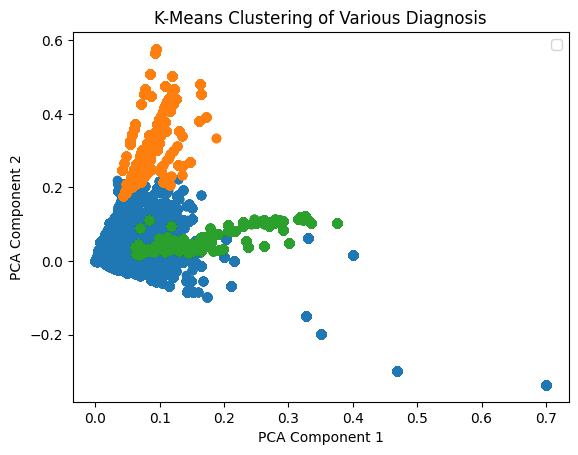

In [12]:
for i in range(num_clusters):
    plt.scatter(reduced_data[kmeans.labels_ == i, 0], 
                reduced_data[kmeans.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Various Diagnosis')
plt.show()

In [13]:
df_admit_diagnosis['diagnosis_cluster'] = kmeans.labels_
print(df_admit_diagnosis['diagnosis_cluster'].value_counts())

diagnosis_cluster
0    5454383
2     543744
1     486632
Name: count, dtype: int64


In [14]:
df_admit_diagnosis.drop(columns = ['icd_version_y','subject_id_y'],axis = 1,inplace = True)
df_admit_diagnosis.rename(columns={'icd_version_x': 'icd_version','subject_id_x':'subject_id'}, inplace=True)

In [15]:
df_admit_diagnosis.head(5)

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version,icd_diagnosis_name,diagnosis_cluster
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,1.0,5723,9.0,Portal hypertension,0
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,2.0,78959,9.0,Other ascites,0
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,3.0,5715,9.0,Cirrhosis of liver without mention of alcohol,0
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,4.0,07070,9.0,Unspecified viral hepatitis C without hepatic ...,0
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,5.0,496,9.0,"Chronic airway obstruction, not elsewhere clas...",0


In [47]:
# Encoding diagnosis table

# combine diagnosis cluster into one admisison per row

df_admit_diagnosis_encoded = pd.get_dummies(df_admit_diagnosis, columns=['diagnosis_cluster'], dtype = int)
df_admit_diagnosis_encoded.drop(columns= ['admittime','dischtime','deathtime','admit_provider_id','marital_status','edouttime','hospital_expire_flag',
                                          'seq_num','icd_code','icd_version','language','icd_diagnosis_name'],inplace= True)
df_admit_diagnosis_encoded.head(5)  

,subject_id,hadm_id,admission_type,admission_location,discharge_location,insurance,race,edregtime,diagnosis_cluster_0,diagnosis_cluster_1,diagnosis_cluster_2
0,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,2180-05-06 19:17:00,1,0,0
1,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,2180-05-06 19:17:00,1,0,0
2,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,2180-05-06 19:17:00,1,0,0
3,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,2180-05-06 19:17:00,1,0,0
4,10000032,22595853,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,2180-05-06 19:17:00,1,0,0


In [48]:
df_admit_diagnosis_encoded = df_admit_diagnosis_encoded.groupby(['hadm_id', 'subject_id']).agg({
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'edregtime':'first',
     'insurance':'first',
     'race':'first',
     'diagnosis_cluster_0':'sum',
     'diagnosis_cluster_1':'sum',
     'diagnosis_cluster_2':'sum',
     }).reset_index()
df_admit_diagnosis_encoded.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,edregtime,insurance,race,diagnosis_cluster_0,diagnosis_cluster_1,diagnosis_cluster_2
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 18:56:00,Medicaid,HISPANIC/LATINO - GUATEMALAN,9,1,2
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 15:03:00,Medicare,WHITE,9,1,0
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,None,Medicare,BLACK/CARIBBEAN ISLAND,20,5,3
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,None,Private,WHITE,8,2,0
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 11:41:00,Private,WHITE,15,2,0


In [54]:
# Assign admission ranks throughout time
df_admit_diagnosis_encoded['admission_rank'] = df_admit_diagnosis_encoded.groupby('subject_id')['edregtime'].rank(method='dense', ascending=True)
df_admit_diagnosis_encoded.drop(columns=['edregtime'], inplace= True)
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_cluster_0,diagnosis_cluster_1,diagnosis_cluster_2,admission_rank
141961,22595853,10000032,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,7,1,0,1.0
155119,22841357,10000032,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,WHITE,8,0,0,2.0
313493,25742920,10000032,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,WHITE,11,0,0,4.0
495453,29079034,10000032,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,WHITE,14,0,0,3.0


In [55]:
# label encode the text columns
cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis_encoded[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_cluster_0,diagnosis_cluster_1,diagnosis_cluster_2,admission_rank
141961,22595853,10000032,8,8,6,0,28,7,1,0,1.0
155119,22841357,10000032,5,2,6,0,28,8,0,0,2.0
313493,25742920,10000032,5,2,8,0,28,11,0,0,4.0
495453,29079034,10000032,5,2,6,0,28,14,0,0,3.0


In [ ]:
# Clean and encode medi table first before joining onto main table

#df_medi[df_medi['hadm_id'].isin(df_admits['hadm_id'])]
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [59]:
# Apply K-means clustering for medication

vectorizer_medi = TfidfVectorizer()        # removes common words
vectorized_words_medi = vectorizer_medi.fit_transform(df_medi['medication'])
reduced_data_medi = svd.fit_transform(vectorized_words_medi)


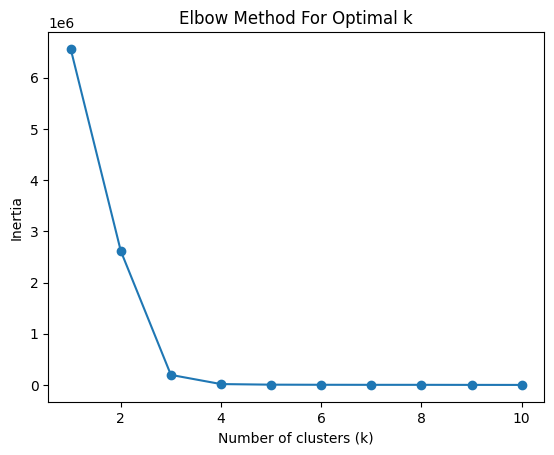

In [ ]:
# Use Elbow Method to determine the number of clusters to use

inertias_medi = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced_data_medi)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias_medi.append(kmeans.inertia_)

plt.plot(K, inertias_medi, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [62]:
num_clusters = 3
kmeans_medi = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans_medi.fit(vectorized_words_medi)

KMeans(max_iter=500, n_clusters=3, n_init=5, random_state=42)

C:\Users\Saaqib\AppData\Local\Temp\ipykernel_27416\3777018470.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Saaqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


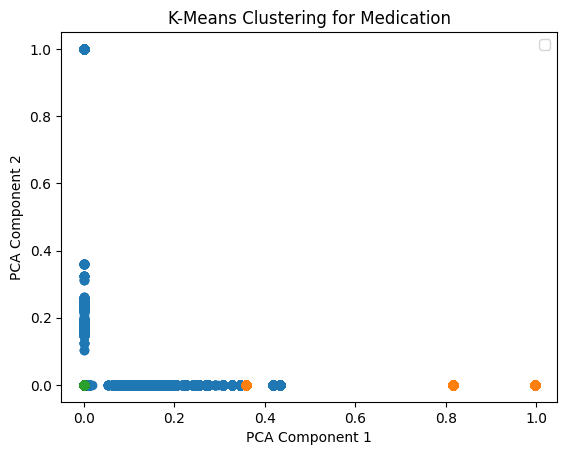

In [64]:
for i in range(num_clusters):
    plt.scatter(reduced_data_medi[kmeans_medi.labels_ == i, 0], 
                reduced_data_medi[kmeans_medi.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering for Medication')
plt.show()